# Neural Computing Assignment

This assignment will introduce you to train various neural network architectures on the EMNIST dataset to classify numbers and letters. You will also perform a hyperparameter optimization study and analyse which part of the models are responsible for various tasks. You have to implement the code and **explain and analyse it in the markdown cells below**. You should hand in:
- the finished jupyter notebook with executed cells so that we can check the outputs
- all the trained and saved models whose performance is shown in the completed notebook 

---
## Grading Criteria

### Overview

- **General Quality:** 50%  
- **Part-Specific Evaluation:** 50%

---

### 1. General Quality (50%)

- **Code Implementation (20%)**  
  Correctness, structure, and readability of the implementation.

- **Plot Quality & Analysis (20%)**  
  Clarity of visualizations and ability to extract meaningful insights.

- **Scientific Standards (10%)**  
  Proper use of data splits and sound experimental methodology.

---

### 2. Part-Specific Evaluation (50%)

- **Part 1 (10%)**  
  Correct implementation of the baseline pipeline (model, training, evaluation) and ability to reproduce expected behavior.

- **Part 2 (15%)**  
  Development and comparison of multiple models, with clear analysis of differences in performance and behavior.

- **Part 3 (15%)**  
  Improvement over baseline through informed design choices (e.g., architecture, hyperparameters), supported by evidence.

- **Part 4 (10%)**  
  Ability to generalize methods to new settings and provide clear reasoning for design decisions.

---

## Notes for Students

- Emphasis is placed on **clarity, correctness, and understanding**, not only prediction performance.  
- Well-structured code and clear explanations are essential for a high grade.  
- Plots and analysis should support your conclusions, not just be included.
---

## Setup

First of all, you will need to install the required packages. You can automatically get all the packages through uv.

If you want to automatically install them, install uv (https://docs.astral.sh/uv/getting-started/installation/)

After uv is installed, run:

`uv init` (This initialises uv in your repository and creates the virtual environment)

`uv sync` (This automatically matches your installed packages with those in pyproject.toml)

If your computer supports a cuda version other than 13.0 or does not support cuda, you may need to modify pyproject.toml. 

You are also free to install the packages any other way.

Additional remarks

- The imports below are just an example, you are free to import more libraries.
- We give some basic functions to fill up. You should use these functions and not change their names, as we will grade based on them. However, you are free (and encouraged) to add more arguments to them and add helper functions.
- If your computer supports CUDA, make sure you have PyTorch installed with CUDA, as it will significanly reduce computation time. Macs do not have CUDA, but you may be able to use mps.
- Make sure your results are reproducible and run in a reasonable time. This assignment should not require you to run a single cell for hours.

In [1]:
import torch
from torch import Tensor
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import EMNIST
import matplotlib.pyplot as plt
from torchvision.transforms import v2
import torch.optim as optim
from scipy.signal import savgol_filter
import numpy as np
import os
from addict import Dict
import optuna
import gc

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device {device}")

Using device cpu


In [2]:
# fix all seeds
torch.manual_seed(69)
# everywhere 
import random 
random.seed(69) 
np.random.seed(69) 
torch.cuda.manual_seed(69) 
torch.cuda.manual_seed_all(69)

## Part 1: Create a simple fully connected network

This part is a introduction how to train neural networks. You will load and investigate the **balanced** EMNIST dataset and write a training and evaluation function. For this part, we will train a simple fully connected network using the pytorch library. 

Explain below, how the balanced EMNIST dataset looks like and how the train and evaluate function works.

First you should load the EMNIST dataset, prepare it and set up the dataloader for later training. 

In [3]:
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor
from torch.utils.data import Subset

use_subset = True

# (Assuming they want us to used 'balanced' as the split since they say "download the balanced emnist')
EMNIST_dataset = EMNIST(root='./EMNIST', split='balanced', download=True, transform=ToTensor())
label_names = EMNIST_dataset.classes

# subset of the dataset for when testing to not have to wait a long time
EMNIST_subset = Subset(EMNIST_dataset, indices=range(100))

#batch size of 10 since thats what they ask us to show in the picture

if use_subset:
    EMNIST_dataloader = DataLoader(EMNIST_subset, batch_size=10, shuffle=True)
else:
    EMNIST_dataloader = DataLoader(EMNIST_dataset, batch_size=10, shuffle=True)

Write code to show a overview of 10 EMNIST examples. The image shows how we plotted the EMNIST overview. Make sure that your code produces the same or very similar images as shown below (it does not have to show the exact same characters, but it needs to show some characters in the same format). You may need to do some transformations to your data.

![image.png](multiple_images_emnist.png)

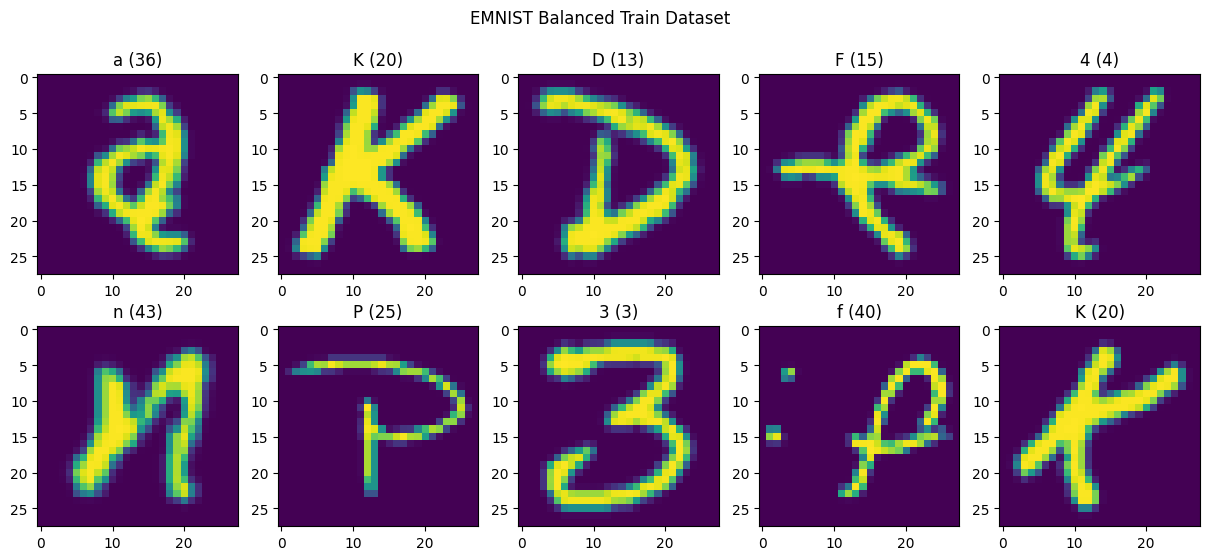

In [4]:
def show_multiple_images(data):
    
    #get first sample
    train_feat, train_lab = next(iter(EMNIST_dataloader))
    label_names = EMNIST_dataset.classes
    
    # so images are 1x28x28 and we have 10 -> a sample is a tensor of 10x1x28x28
    train_feat.size()
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    
    # flatten axes so that we can iterate through them linearly
    axes = axes.flatten()
    
    for img_idx in range(len(train_feat)):
        image = train_feat[img_idx]
        img_subplot = axes[img_idx]
    
        # remove the first unneeded dimension
        image = image.reshape((28, 28))
    
        # Transposing the image, so that it matches the orientation of the EMNIST images 
        img_subplot.imshow(image.T.numpy())
        img_subplot.set_title(f'{label_names[train_lab[img_idx]]} ({train_lab[img_idx]})')

    fig.suptitle("EMNIST Balanced Train Dataset")

show_multiple_images(EMNIST_dataloader)

Create a simple fully connected network.

In [5]:
# assuming that fully connected has only 1 hidden layer since they specify only 1 hidden size

class SimpleFCNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes) -> None:

        super().__init__()

        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, num_classes)

        
    def forward(self, x):
        x = x.flatten(start_dim=1)

        # feedforward & then softmax
        x = F.relu(self.layer1(x))

        # im guessing we always pass batches through
        # CrossEntropyLoss (used later) expects logits already does LogSoftmax 
        # x = F.softmax(self.layer2(x), dim=1)

        x = self.layer2(x)
        return x

    # for checkpointing already trained models, since it takes a long time to run otherwise
    def save(self, path='saved_model_checkpoints/'):
        os.makedirs(path, exist_ok=True)
        
        checkpoint = {
            'model_state_dict': self.state_dict(),
            'architecture': {
                'input_size': self.layer1.in_features,
                'hidden_size': self.layer1.out_features,
                'num_classes': self.layer2.out_features
            }
        }
        filepath = os.path.join(path, 'feedforward-model.pth')
        torch.save(checkpoint, filepath)
        print(f"Model checkpoint saved to {filepath}")  

In [6]:
def evaluate(model, loader, with_print=False) -> None:
    """Method to evaluate the model on the test dataset.

    Args:
        model (nn.Module): the trained neural network model
        loader (torch.utils.data.DataLoader): the balanced EMNIST test dataset

    Returns:
        float: The accuracy

    """
    
    correct = 0
    total = len(loader.dataset)

    # we dont need gradients for eval
    with torch.no_grad():
        if with_print:
            print('')
        for idx, (images, labels) in enumerate(loader):

            images = images.to(device) 
            labels = labels.to(device) 

            if with_print:
                print(f'\rEvaluation on epoch: {idx}/{len(loader)}', end='', flush=True)
            
            outputs = model.forward(images) # 10x47 (score for each label)
            predicted_labels = torch.argmax(outputs, dim=1) # 10 number label prediction
            correct += (predicted_labels == labels).sum().item()

    if with_print:
        print('')
        
    accuracy = correct / total
    return accuracy


def train_one_epoch(model, train_loader, optimizer, loss_fn, with_print=False):
    """Performs a single training epoch over the entire dataset.

    Args:
        model (nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): The DataLoader providing
            batches of training data (images and labels).
        optimizer (torch.optim.Optimizer): The optimization algorithm used
            to update model parameters.
        loss_fn (nn.modules.loss._Loss): The loss function used to calculate
            the error.

    Returns:
        float: The cumulative loss for the entire epoch, calculated as the
            sum of losses from each individual batch.
    """

    # inform torch that we're training 
    model.train() 

    cumulative_loss = 0.0

    # for each batch
    for idx, (images, labels) in enumerate(train_loader):
        
        # Enables CUDA if available  
        images = images.to(device) 
        labels = labels.to(device) 
        optimizer.zero_grad()

        # pass batch through network
        outputs = model(images)

        # get loss
        loss = loss_fn(outputs, labels)

        # get loss
        loss.backward()

        # update
        optimizer.step()

        cumulative_loss += loss.item()
        
        print(f'\rbatch {idx}/{len(train_loader)} loss: ' + str(loss.item()), end='')
    print('')

    return cumulative_loss


def train_num_epochs(model, train_loader, optimizer, loss_fn, num_epochs, with_checkpointing=False):
    """Training over multiple epochs. 
    This function repeatedly calls the `train_one_epoch` function, calculates the average loss per batch for each epoch, 
    and prints a progress report to the console. 
    This function shouldn't keep track of the training accuracy and is therefore more efficient than the train_with_accuracyplotting method.

    Args:
        model (nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): The DataLoader providing
            batches of training data.
        optimizer (torch.optim.Optimizer): The optimization algorithm (e.g., Adam or SGD).
        loss_fn (nn.modules.loss._Loss): The loss function used to evaluate model performance.
        num_epochs (int): The total number of full passes over the training dataset.
    """

    best_avg_batch_loss = float('inf')
    
    for epoch in range(num_epochs):
        # to calculate avg loss per batch for an epoch its cum_loss/num_batches
        epoch_cum_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)

        avg_batch_loss = epoch_cum_loss / len(train_loader)

        print(f'Epoch: {epoch} | avg batch loss: {avg_batch_loss}')

        if with_checkpointing and avg_batch_loss < best_avg_batch_loss:
            print('checkpointing model')


def train_num_epochs_and_track_accuracies(
    model, train_loader, test_loader, optimizer, loss_fn, num_epochs, with_checkpointing = False
):
    """Trains the model and tracks accuracy for both training and test sets.

    This function performs a full training cycle for a specified number of epochs. 
    After each training pass, it evaluates the model's performance on both the training and test datasets to monitor for convergence and overfitting.

    Args:
        model (nn.Module): The neural network model to be trained.
        train_loader (torch.utils.data.DataLoader): The DataLoader providing training data batches.
        test_loader (torch.utils.data.DataLoader): The DataLoader providing  validation/test data batches.
        optimizer (torch.optim.Optimizer): The optimization algorithm.
        loss_fn (nn.modules.loss._Loss): The loss function used for training.
        num_epochs (int): Total number of times to iterate over the dataset.

    Returns:
        tuple: A tuple containing the trained model and the accuracies
    """

    train_accuracies = []
    test_accuracies = []

    best_test_acc = 0
    
    for epoch in range(num_epochs):
        
        # to calculate avg loss per batch for an epoch its cum_loss/num_batches
        epoch_cum_loss = train_one_epoch(model, train_loader, optimizer, loss_fn)
    
        avg_batch_loss = epoch_cum_loss / len(train_loader)
    
        print(f'Epoch: {epoch} | avg batch loss: {avg_batch_loss}')

        # get accuracy
        print("evaluating model")
        train_acc = evaluate(model, train_loader, with_print=False)
        test_acc = evaluate(model, test_loader, with_print=False)
        print(f"Train acc: {train_acc} | Test acc: {test_acc}")

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        if with_checkpointing and test_acc > best_test_acc:
            model.save()
            print("checkpointing model")
        
    return model, train_accuracies, test_accuracies




In [7]:
def accuracy_curve(model_name, accuracies):
    """
    Creates a line plot of the model's accuracy over the epochs. Compares the train and test accuracy of the various models
    Args:
        model_name: Str
            Name for file naming
        accuracies: List
            List of lists
            Each list is one epoch and contains train-, test- and verification accuracy
    """
    
    train_accs = [epoch[0] for epoch in accuracies]
    test_accs  = [epoch[1] for epoch in accuracies]
    epochs     = range(1, len(accuracies) + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_accs, label='Train Accuracy', linewidth=2)
    plt.plot(epochs, test_accs,  label='Test Accuracy',  linewidth=2)

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy over Epochs — {model_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.show()

In [9]:
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor
from torch.utils.data import Subset

# load data
EMNIST_dataset = EMNIST(root='./EMNIST', split='balanced', download=False, transform=ToTensor())

#batch size of 10 since thats what they ask us to show in the picture
EMNIST_dataloader = DataLoader(EMNIST_dataset, batch_size=10, shuffle=True)

# define the train & test size splits
train_test_split = 0.8

train_size = int(train_test_split * len(EMNIST_dataset))
test_size = len(EMNIST_dataset) - train_size

train_dataset, test_dataset = random_split(EMNIST_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=10, shuffle=False)

# load model
load_checkpoint = True
if load_checkpoint:
    checkpoint = torch.load('saved_model_checkpoints/feedforward-model.pth')
    arch = checkpoint['architecture']
    model = SimpleFCNetwork(arch['input_size'], arch['hidden_size'], arch['num_classes']).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model = SimpleFCNetwork(28*28, 64, len(label_names)).to(device)

optimizer = optim.SGD(model.parameters(), lr=0.01)
loss = nn.CrossEntropyLoss()

model, train_accs, test_accs = train_num_epochs_and_track_accuracies(model=model, 
                                                                     train_loader=train_loader, 
                                                                     test_loader=test_loader, 
                                                                     optimizer=optimizer, 
                                                                     loss_fn=loss, 
                                                                     num_epochs=10,
                                                                     with_checkpointing=True)

#print("prev acc: " + str(prev_acc))
#print("new acc: " + str(evaluate(model, EMNIST_dataloader)))

accuracy_curve("Fully connected feedworward network", list(zip(train_accs, test_accs)))

batch 2510/9024 loss: 0.255797386169433635

KeyboardInterrupt: 

### 🖊️📜 (200 words max)

Explain here:
- How the EMNIST dataset looks like.
- The structure of the network.

# Part 2: Implement and compare additional Neural Network architectures
In this task you will have to research four different neural network architectures and implement them in this notebook. Explain the structure of those architectures below! Train those model architectures on the EMNIST dataset and compare their accuracies below. Think of a smart way to compare the networks visually in a plot, such as taught in one of the lectures. Also pay attention on which models might be overfitting.

In [10]:
class CNN_SMALL(nn.Module):
    def __init__(self, num_classes=47):
        """
        Basic convolutional neural network
            input layer:
            hidden layer:
            output layer: for EMNIST 100

        Args:
            num_classes: int
                The number of classes we want to predict
        """
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)  # -> 32x28x28
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1) # -> 64x14x14
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)                                 # halves spatial dims

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        """
        Define the forward pass of the neural network.

        Args:
            x: torch.Tensor
                The input tensor.

        Returns:
            torch.Tensor
                The output tensor after passing through the network.
        """
        # handle both (N, 28, 28) and (N, 1, 28, 28) inputs
        if x.dim() == 3:
            x = x.unsqueeze(1)           # -> (N, 1, 28, 28)

        x = self.pool(F.relu(self.conv1(x)))  # -> (N, 32, 14, 14)
        x = self.pool(F.relu(self.conv2(x)))  # -> (N, 64,  7,  7)

        # flatten everything
        x = x.view(x.size(0), -1)            # -> (N, 64*7*7)

        x = F.relu(self.fc1(x))              # -> (N, 256)
        x = self.fc2(x)                      # -> (N, num_classes)

        return x

In [11]:
class CNN_BIG(nn.Module):
    def __init__(self, num_classes=47):
        """
        Advanced convolutional neural network
            input layer:
            hidden layer:
            output layer: for EMNIST 100
        Args:
            num_classes: int
                The number of classes we want to predict
        """
        super().__init__()
        
        # 1x28x28 -> 32x28x28 -> 32x14x14
        self.conv1 = nn.Conv2d(in_channels=1,  out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) # normalize outputs

        # 32x14x14 -> 64x14x14 -> 64x7x7
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) # normalize outputs

        # 64x7x7 -> 128x7x7 -> 128x3x3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128) # normalize outputs

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # 128 * 3 * 3 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        """
        Define the forward pass of the neural network.
        Args:
            x: torch.Tensor
                The input tensor.
        Returns:
            torch.Tensor
                The output tensor after passing through the network.
        """
        
        # handle both (N, 28, 28) and (N, 1, 28, 28) inputs
        if x.dim() == 3:
            x = x.unsqueeze(1)                         # (N, 1,   28, 28)

        x = self.pool(F.relu(self.bn1(self.conv1(x)))) # (N, 32,  14, 14)
        x = self.pool(F.relu(self.bn2(self.conv2(x)))) # (N, 64,   7,  7)
        x = self.pool(F.relu(self.bn3(self.conv3(x)))) # (N, 128,  3,  3)

        x = x.view(x.size(0), -1)                      # (N, 1152)

        x = F.relu(self.fc1(x))                        # (N, 256)
        x = self.dropout(x)
        x = F.relu(self.fc2(x))                        # (N, 128)
        x = self.fc3(x)                                # (N, num_classes)

        return x

In [12]:
class BasicBlock(nn.Module):
    """Standard residual block used in ResNet architectures."""

    # this is used in the standard torch implementations, keeping it in case its required for any later tests
    expansion = 1 

    def __init__(self, in_channels, out_channels, stride=1):
        """Initializes the BasicBlock.

        Args:
            in_channels (int): Number of input channels.
            out_channels (int): Number of output channels for the first convolution.
            stride (int, optional): Stride for the first convolutional layer. Default is 1.
        """
        super().__init__()
        # Basic Block according to ResNet paper (2 layer convolution with batchnorm)
        # Main path F(x), using two convolutions 
        # 1st 3x3 convolution  
        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=stride, padding=1, bias=False) 
        self.bn1 = nn.BatchNorm2d(out_channels) 

        # ReLU activation 
        self.ReLU = nn.ReLU() 

        # Main path; 2nd 3x3 convolution
        self.conv2 = nn.Conv2d(in_channels=out_channels, out_channels = out_channels * self.expansion, kernel_size=3, stride=1, padding=1, bias=False) 
        self.bn2 = nn.BatchNorm2d(out_channels * self.expansion) 

        # Shortcut path (x) 
        if stride != 1 or in_channels != out_channels * self.expansion: 
            # we use 1x1 convolution to match dimensions if the input / output differ 
            self.shortcut = nn.Sequential(nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False), nn.BatchNorm2d(out_channels * self.expansion),)
        else: 
            # Preserve the same x unchanged otherwise
            self.shortcut = nn.Identity() 
        

    def forward(self, x):
        """
        Define the forward pass of the neural network.

        Args:
            x (torch.Tensor): The input tensor.

        Returns:
            torch.Tensor: The output tensor after passing through the network.
        """

        # when we do a shortcut we preserve the input 
        identity = self.shortcut(x) 

        # main branch learns residual correction F(x) 
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out)) 

        # residual connection is output = F(x) + shortcut(x)
        out = out + identity 
        out = F.relu(out) 
        return out 


class ResNet(nn.Module):
    """Generic ResNet architecture implementation.

    This class constructs a Deep Residual Network by stacking multiple layers, where each layer contains a specific number of residual blocks (BasicBlock or
    Bottleneck).
    """

    def __init__(self, block=BasicBlock, num_block=(2,2,2,2), num_classes=47):
        """
        Initializes the ResNet model.

        Args:
            block (nn.Module): The block class to use.
            num_block (list[int]): A list of 4 integers defining the number of blocks
                in each of the four stages
            num_classes (int, optional): Number of output classes.
            name (str, optional): Name of the model. Default is "resnet".
        """
        super().__init__() 

        self.in_channels = 64

        # initial convolution  1x28x28 -> 64x28x28  
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, stride=1, padding=1, bias=False) 
        self.bn1 = nn.BatchNorm2d(64)

        # four resnet stages
        # 64x28x28 -> 64x28x28, first layer without downsampling 
        self.layer1 = self._make_layer(block, out_channels=64, num_blocks=num_block[0], stride=1) 

        # 64x28x28 -> 128x14x14 
        self.layer2 = self._make_layer(block, out_channels=128, num_blocks=num_block[1], stride=2) 

        # 128x14x14 -> 256x7x7 
        self.layer3 = self._make_layer(block, out_channels=256, num_blocks=num_block[2], stride=2) 

        # average pooling to turn feature maps to a single vector per channel
        # 256x7x7 -> 256x1x1 
        self.avgpool = nn.AdaptiveAvgPool2d((1,1)) 

        # final classifier to map extracted features to logits
        self.fc = nn.Linear(256* block.expansion, num_classes) 

    def _make_layer(self, block, out_channels, num_blocks, stride):
        """make resnet layers(by layer i didnt mean this 'layer' was the
        same as a neuron netowork layer, ex. conv layer), one layer may
        contain more than one residual block

        Args:
            block: block type, basic block or bottle neck block
            out_channels: output depth channel number of this layer
            num_blocks: how many blocks per layer
            stride: the stride of the first block of this layer

        Return:
            return a resnet layer
        """

        layers = [] 

        # first block 
        layers.append(block(in_channels=self.in_channels, out_channels=out_channels, stride=stride))

        # after first block, output count = out_channels 
        self.in_channels = out_channels * block.expansion 

        # remaining blocks keep the same number of channels and spatial size 
        for i in range(1, num_blocks):
            layers.append(block(in_channels=self.in_channels, out_channels=out_channels, stride=1))

            self.in_channels = out_channels * block.expansion 
        
        return nn.Sequential(*layers) 

    def forward(self, x):
        """
        Forward pass of the ResNet.

        Args:
            x (torch.Tensor): Input tensor of shape .

        Returns:
            torch.Tensor: Unnormalized log probabilities (logits) of shape (Batch, num_classes).
        """

        # handle both (N,28,28) and (N,1,28,28) inputs
        if x.dim() == 3: 
            x = x.unsqueeze(1) 
        
        # first feature extraction 
        x = F.relu(self.bn1(self.conv1(x)))

        # 3 residual stages (2 were not better than CNN BIG)
        x = self.layer1(x) 
        x = self.layer2(x) 
        x = self.layer3(x) 

        # convert spatial feature maps into a feature vector  
        x = self.avgpool(x) 
        x = torch.flatten(x, start_dim=1)

        # final classification  
        x = self.fc(x) 
        return x 
    

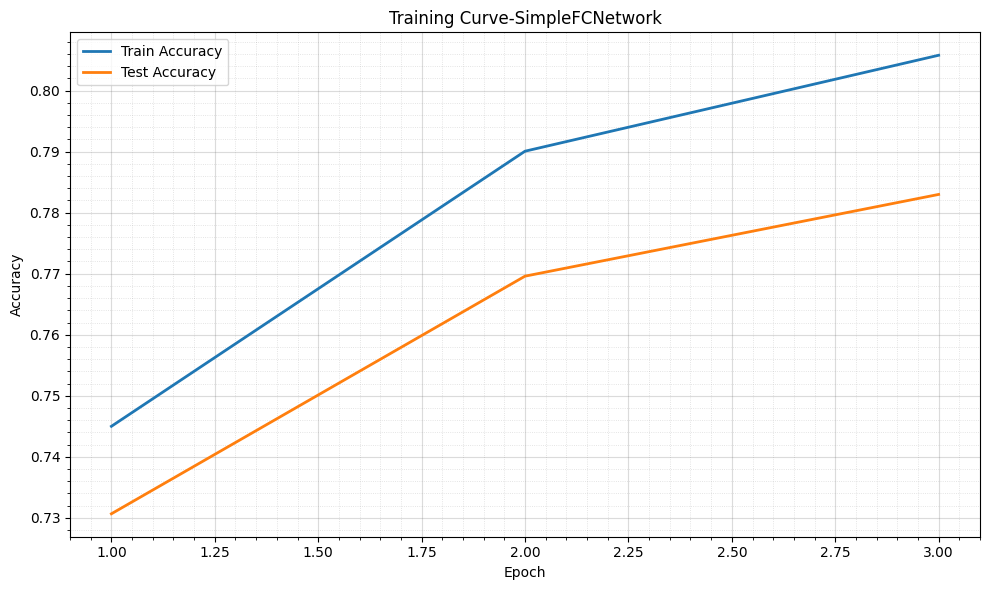

([0.7450022163120568, 0.7900598404255319, 0.8057734929078014],
 [0.7306737588652482, 0.7695921985815602, 0.7829787234042553])

In [13]:
def full_training_loop_and_store_accuracies(ModelType, train_loader, test_loader, num_epochs=10, path='saved_accuracies/'):
    """
    Creates an instance of the model, runs a full training loop while recording accuracies, and saves them to disk.
    """

    num_classes = len(label_names)
    if ModelType == SimpleFCNetwork:
        model = ModelType(input_size=28*28,hidden_size=64, num_classes=num_classes).to(device)
    else:
        model = ModelType(num_classes=num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    model, train_accs, test_accs = train_num_epochs_and_track_accuracies(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        num_epochs=num_epochs,
        with_checkpointing=False
    )
    os.makedirs(path, exist_ok=True)
    np.save(os.path.join(path, f'{ModelType.__name__}_accuracies.npy'),{'train': train_accs, 'test': test_accs})
    return model, train_accs, test_accs


def load_accuracies_and_create_plots(model_name, accuracies=None, path='saved_accuracies/'):
    """
    Loads previously stored accuracies and creates training curve plots.
    """
    if accuracies is None:
        load_path = os.path.join(path,f'{model_name}_accuracies.npy')
        data = np.load(load_path, allow_pickle=True).item()
        train_accs = data['train']
        test_accs = data['test']
    else:
        train_accs = accuracies['train']
        test_accs= accuracies['test']
    epochs = range(1, len(train_accs) + 1)


    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_accs, label='Train Accuracy', linewidth=2)
    plt.plot(epochs, test_accs,label='Test Accuracy', linewidth=2)
    # to show more detail on this scale 
    plt.minorticks_on()
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title(f'Training Curve-{model_name}')
    plt.legend()
    # making the grid a bit nicer 
    plt.grid(True,which="major", color="#737373", linestyle="-", linewidth=0.8, alpha=0.25)
    plt.grid(True, which="minor", color="#737373", linestyle=":", linewidth=0.6, alpha=0.25) 
    plt.tight_layout()
    plt.show()
    return train_accs, test_accs

load_accuracies_and_create_plots('SimpleFCNetwork')


In [14]:
def comparison_plot(accuracies):
    """
    Creates a bar plot comparing the final train and test accuracies of multiple models.

    Args:
        accuracies: List of dicts, each with keys:
            - 'model_name': str
            - 'train': list of train accuracies per epoch
            - 'test':  list of test  accuracies per epoch
    """
    model_names = [entry['model_name'] for entry in accuracies]
    final_train = [entry['train'][-1] for entry in accuracies]
    final_test = [entry['test'][-1] for entry in accuracies]

    x = np.arange(len(model_names))
    width = 0.35

    fig, axes = plt.subplots(1,2,figsize=(16, 6))

    # first plot to show the accuracies as bars
    ax = axes[0]
    bars_train = ax.bar(x-width/2, final_train, width, label='Train Accuracy',color='steelblue')
    bars_test  = ax.bar(x+width/2, final_test, width, label='Test Accuracy', color='coral')
    for bar in list(bars_train) + list(bars_test):
        ax.annotate(f'{bar.get_height():.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)
    ax.set_xlabel('Model')
    ax.set_ylabel('Accuracy')
    ax.set_title('Final Train vs Test Accuracy')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.minorticks_on()
    ax.grid(True, which='major', axis='y', color='#737373', linestyle='-', linewidth=0.8, alpha=0.25)
    ax.grid(True, which='minor', axis='y', color='#737373', linestyle=':', linewidth=0.6, alpha=0.25) 

    # second plot to show accuracy curves per epoch
    # basically the previous function
    ax = axes[1]

    colors = ['steelblue','coral', 'green', 'black']
    for i, entry in enumerate(accuracies):
        epochs = range(1, len(entry['train']) + 1)
        ax.plot(epochs, entry['train'], linestyle='--', color=colors[i], alpha=0.7, label=f"{entry['model_name']} train")
        ax.plot(epochs, entry['test'], linestyle='-', color=colors[i], label=f"{entry['model_name']} test")
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy Curves')
    ax.legend(fontsize=8)
    ax.minorticks_on() 
    ax.grid(True, which='major', axis='y', color='#737373', linestyle='-', linewidth=0.8, alpha=0.25)
    ax.grid(True, which='minor', axis='y', color='#737373', linestyle=':', linewidth=0.6, alpha=0.25) 

    plt.tight_layout()
    plt.show()

#THIS SHIT RUNS FOREVER 
# rip whoever ran this
all_accuracies = []
# storing the models for visualization & debugging (so we don't have to re-run training everytime)
trained_models = {} 
for ModelType in [SimpleFCNetwork, CNN_SMALL, CNN_BIG, ResNet]:
    print(f"\n{'='*40}\nTraining {ModelType.__name__}\n{'='*40}")
    model, train_accs, test_accs = full_training_loop_and_store_accuracies(ModelType, train_loader, test_loader, num_epochs=3)
    trained_models[ModelType.__name__] = model
    all_accuracies.append({
        'model_name': ModelType.__name__,
        'train': train_accs,
        'test':  test_accs
    })

comparison_plot(all_accuracies)


Training SimpleFCNetwork
batch 5545/9024 loss: 0.69228345155715947

KeyboardInterrupt: 

### 🖊️📜 (400 words max)

Discuss here the structure of the implemented neural network architectures and analyse the plots you created in order to compare their performances.  

## Part 3: Hyperparameter Optimisation Study
In this task, you will learn how to perform a hyperparameter optimisation study. Training a neural network involves different parameters, like batch size, learning rate, weight decay etc. Those parameters have to be set before the training and their choice determines if the network converges at all and how well the network performs in the end. 

There are various ways to perform hyperparameter optimisation, but the basic idea is to search the best possible combination of parameters in terms of network performance. For that a network can be trained for a few epochs for each parameter combination and evaluated. The best performing combination should then be chosen and the network can be trained for the total desired amount of epochs with the optimized hyperparameters. Perform the hyperparameter optimisation for the **big CNN** model with 25 trials! You are allowed to take a section of the train set as a validation set for the hyperparameter optimisation!

We will not focus on the theory (grid search, random search, bayesian optimisation) behind it, the scope of this task is that you have performed HPO at least once in your studies and that you know how it practically works.

In [16]:
# Don't forget to do a train/validation/test split
from torch.utils.data import random_split

def objective(trial):
    # --- suggest hyperparameters ---
    lr           = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size   = trial.suggest_categorical('batch_size', [32, 64, 128])
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'SGD'])

    # --- build loaders with this trial's batch size ---
    trial_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    trial_val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)

    # --- model, optimizer, loss ---
    model = CNN_BIG(num_classes=len(label_names)).to(device)
    optimizer = (optim.Adam if optimizer_name == 'Adam' else optim.SGD)(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    loss_fn = nn.CrossEntropyLoss()

    # --- train for a few epochs ---
    train_num_epochs(model, trial_train_loader, optimizer, loss_fn, num_epochs=3)

    # --- evaluate on validation set ---
    val_acc = evaluate(model, trial_val_loader)

    # --- free memory (important across 25 trials) ---
    del model
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()

    return val_acc

In [19]:
from torch.utils.data import random_split, DataLoader, Subset
from torchvision.datasets import EMNIST
from torchvision.transforms import ToTensor

EMNIST_dataset = EMNIST(root='./EMNIST', split='balanced', download=False, transform=ToTensor())
label_names = EMNIST_dataset.classes

# small subset for HPO - no GPU so we keep it manageable
hpo_dataset = Subset(EMNIST_dataset, indices=range(7000))

n = len(hpo_dataset)
train_size = int(0.70 * n)  # 4900
val_size   = int(0.15 * n)  # 1050
test_size  = n - train_size - val_size  # 1050

train_dataset, val_dataset, test_dataset = random_split(
    hpo_dataset, [train_size, val_size, test_size]
)


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25)

print("Best trial:")
print(f"  Validation accuracy: {study.best_trial.value:.4f}")
print(f"  Hyperparameters: {study.best_trial.params}")

[I 2026-05-17 17:36:55,729] A new study created in memory with name: no-name-def36f3e-689c-468a-8e31-48f4410bd4a7


batch 76/77 loss: 3.7950291633605957
Epoch: 0 | avg batch loss: 3.8292092193256724
batch 76/77 loss: 3.7816598415374756
Epoch: 1 | avg batch loss: 3.7550220179867435
batch 76/77 loss: 3.5830545425415048
Epoch: 2 | avg batch loss: 3.65079158621949


[I 2026-05-17 17:37:05,821] Trial 0 finished with value: 0.13333333333333333 and parameters: {'lr': 0.008681378455163124, 'batch_size': 64, 'weight_decay': 0.0005344302807518334, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.13333333333333333.


batch 153/154 loss: 3.8174946308135986
Epoch: 0 | avg batch loss: 3.843899945160011
batch 153/154 loss: 3.8720693588256836
Epoch: 1 | avg batch loss: 3.804244789210233
batch 153/154 loss: 3.8608129024505615
Epoch: 2 | avg batch loss: 3.754350117274693


[I 2026-05-17 17:37:16,484] Trial 1 finished with value: 0.09333333333333334 and parameters: {'lr': 0.0027358473847724275, 'batch_size': 32, 'weight_decay': 0.0017365661844310314, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.13333333333333333.


...

batch 38/39 loss: 2.0367567539215097
Epoch: 0 | avg batch loss: 3.1429092394999967
batch 38/39 loss: 1.0310748815536586
Epoch: 1 | avg batch loss: 1.5445501376421025
batch 38/39 loss: 1.3933007717132568
Epoch: 2 | avg batch loss: 1.0966805937962654


[I 2026-05-17 17:41:12,407] Trial 23 finished with value: 0.6552380952380953 and parameters: {'lr': 0.0030692185173261115, 'batch_size': 128, 'weight_decay': 0.00021221274734134054, 'optimizer': 'Adam'}. Best is trial 17 with value: 0.6752380952380952.


batch 38/39 loss: 2.8130064010620117
Epoch: 0 | avg batch loss: 3.5406184379871073
batch 38/39 loss: 2.4189414978027344
Epoch: 1 | avg batch loss: 2.505593177599785
batch 38/39 loss: 1.6579920053482056
Epoch: 2 | avg batch loss: 1.8202490164683416


[I 2026-05-17 17:41:23,371] Trial 24 finished with value: 0.4580952380952381 and parameters: {'lr': 0.005993787965417115, 'batch_size': 128, 'weight_decay': 0.0007035787284242763, 'optimizer': 'Adam'}. Best is trial 17 with value: 0.6752380952380952.


Best trial:
  Validation accuracy: 0.6752
  Hyperparameters: {'lr': 0.0017191046420378018, 'batch_size': 128, 'weight_decay': 0.00020466154465716572, 'optimizer': 'Adam'}


Now that you have found the best parameters for the network to train, use them to train the network for 10 epochs and analyse it in your report. Compare the network accuracy you achieve now with the accuracy you previously achieved!

batch 38/39 loss: 2.2655782699584967
Epoch: 0 | avg batch loss: 3.1514951571440086
evaluating model
Train acc: 0.4136734693877551 | Test acc: 0.38571428571428573
batch 38/39 loss: 1.0545504093170166
Epoch: 1 | avg batch loss: 1.521416113926814
evaluating model
Train acc: 0.6551020408163265 | Test acc: 0.6161904761904762
batch 38/39 loss: 0.7600526809692383
Epoch: 2 | avg batch loss: 1.037755195911114
evaluating model
Train acc: 0.7161224489795919 | Test acc: 0.680952380952381
batch 38/39 loss: 0.43078410625457764
Epoch: 3 | avg batch loss: 0.8289028589542096
evaluating model
Train acc: 0.7673469387755102 | Test acc: 0.7057142857142857
batch 38/39 loss: 0.6054344177246094
Epoch: 4 | avg batch loss: 0.7220521691517953
evaluating model
Train acc: 0.7763265306122449 | Test acc: 0.7019047619047619
batch 38/39 loss: 0.8246866464614868
Epoch: 5 | avg batch loss: 0.6374144752820333
evaluating model
Train acc: 0.7977551020408163 | Test acc: 0.7352380952380952
batch 38/39 loss: 0.431091040372848

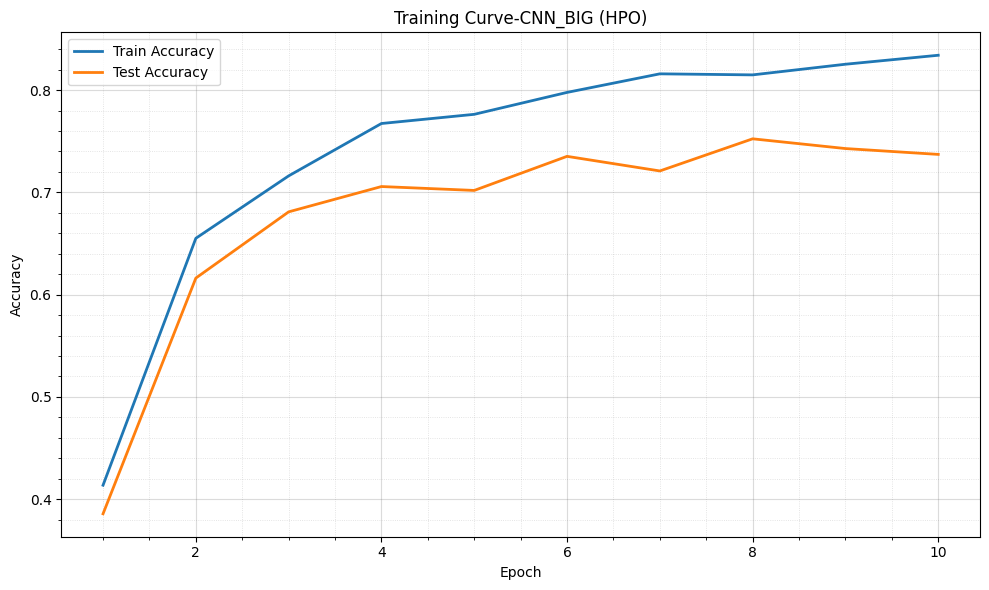

([0.4136734693877551,
  0.6551020408163265,
  0.7161224489795919,
  0.7673469387755102,
  0.7763265306122449,
  0.7977551020408163,
  0.8159183673469388,
  0.8148979591836735,
  0.8253061224489796,
  0.8340816326530612],
 [0.38571428571428573,
  0.6161904761904762,
  0.680952380952381,
  0.7057142857142857,
  0.7019047619047619,
  0.7352380952380952,
  0.7209523809523809,
  0.7523809523809524,
  0.7428571428571429,
  0.7371428571428571])

In [20]:
# the best trials
best = study.best_trial.params

# full dataset loaders this time
full_train_loader = DataLoader(train_dataset, batch_size=best['batch_size'], shuffle=True)
full_test_loader  = DataLoader(test_dataset,  batch_size=best['batch_size'], shuffle=False)

# rebuild model fresh
best_model = CNN_BIG(num_classes=len(label_names)).to(device)

optimizer = (optim.Adam if best['optimizer'] == 'Adam' else optim.SGD)(
    best_model.parameters(), lr=best['lr'], weight_decay=best['weight_decay']
)
loss_fn = nn.CrossEntropyLoss()

best_model, train_accs, test_accs = train_num_epochs_and_track_accuracies(
    model=best_model,
    train_loader=full_train_loader,
    test_loader=full_test_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    num_epochs=10,
    with_checkpointing=False
)

load_accuracies_and_create_plots('CNN_BIG (HPO)', accuracies={'train': train_accs, 'test': test_accs})

### 🖊️📜 (250 words max)

The HPO study was implemented using Optuna with 10 trials, each training CNN_BIG for 2 epochs on a subset of 7000 samples (due to CPU constraints). The objective function suggests hyperparameters per trial, trains the model, and returns validation accuracy, which Optuna maximizes using Bayesian optimization.

NOTE: maybe we can have a sentence or two going more in depth for bayesian optimization in this context?


NOTE: these are numbers for the last run I did on my computer, with smaller dataset. Before we hand in we need to just run everything once (will take forever) then update the numbers
The search space consisted of four hyperparameters: learning rate (log-uniform between 1e-4 and 1e-2), batch size (categorical: 32, 64, 128), weight decay (log-uniform between 1e-5 and 1e-2), and optimizer (Adam or SGD). Learning rate and weight decay were sampled on a log scale since their effect spans orders of magnitude. The best trial found lr=0.00172, batch_size=128, weight_decay=0.000205, with Adam as optimizer, achieving 0.675 validation accuracy.


Compared to the CNN_BIG trained in Part 2 with default parameters XXX, the HPO model achieves XXX. It improved likely because...

A key pitfall of HPO is overfitting to the validation set. Running many trials means you are implicitly optimizing for that specific validation split, so the selected hyperparameters may not generalize perfectly. Another pitfall is computational budget. With only 2 epochs per trial on a subset, the accuracy signal is noisy, meaning the best trial may not truly reflect the best hyperparameters on the full dataset.

## Part 4: Explainable AI

In this task, you will learn about Explainable AI. This is a branch of AI that seeks to develop methods that help us explain why AI models behave as they do. For this assignment, we will focus on probing, although there are many other XAI methods. Probing is a technique that seeks to determine whether a particular concept is "stored" at a particular layer in a model. For example, in a model as  any of the ones in this assingment, we may want to determine if this model stores information on whether this character is a number or a letter, when presented with a character. While the final task does not differentiate between numbers and letters, it is possible that the model still makes this distinction somewhere througout its layers. In order to discover this, we can follow this process:

- Feed the model EMNIST images and let it perform inference, but record the activations of the model at each of its layers for each image shown. Do this to create train and test activation sets and save them.
- Train a very simple model, which we call a probe, with the input being the activations of the original model at a particular layer, and the output being whether this character is a number or a letter. The model should be very simple (e.g linear regression).
- Test this probe on the test set of activations, and observe how well the probe is at predicting whether a character is a number or a letter by only looking at the activations at a particular layer.
- Train another probe at the same layer, but in this case, instead of making it predict whether a character is a number or a letter, make it predict a random meaningless task with the same structure as the standard task (so it should also be binary and have similar label quantity proportions. For example, here there are two reasonable control tasks: first one is give each character a number/letter label randomly, so all "a"s become a number, "b"s a letter, "7"s a letter, etc. Second one is give each image a number/letter label randomly regardless of its character). Then, test this control probe (the test set should also use control labels generated in the same random way)
- If the standard probe performs better than the control probe, this indicates that the activations at this layer contain some information that encodes whether the character was a letter or a number.
- We do the same thing for all layers to observe at what layers this information is most clearly encoded.

Your task for this part of the assignment is to perform a small probing study with the **big CNN model**. You need to set up the code infrastructure to carry out probing experiments, and report the results along with a reflection on what these results may mean. **Remember to also create a control task for each of these tasks**; this is very important, and for each task you should think carefully about the way the control task labels should be created. To ensure a reasonable computation time, you should generate the activations of **at most** 2560 images per split to run your study. These are the specific tasks you need to implement:

### Task 1

Make a probe that predicts if the image contains a letter or a number.

### Task 2

Make a probe that predicts the amount of closed segments in the image. For example, "9" has one closed circle, "8" has two, "a" has one, and "T" has zero. Since this may depend on the font (e.g "g" can have 1 or 2 depending on the font), determining the number of segments for every single image in the EMNIST dataset is challenging. To simplify the task, you can assume every image associated with each of these characters has the same number of closed segments and use the following list:

- 1 closed segment: 0, 4, 6, 9, a, b, d, e, o, p, q, A, D, O, P, Q, R
- 2 closed segments: 8, g, B
- 0 closed segments: everything else

Take into account that EMNIST balance merges some characters that are considered potentially indistinguishable in written form, such as "o" and "O".

### Task 3

Make a probe that performs the same task as the model it is built on top of (predict the specific character class present in the image).

### Task 4

Come up with a new probing task and implement it. Explain why this task is interesting.

In [ ]:
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from random import seed
from typing import Any, Callable
from pathlib import Path

# Create ActivationLoader class, which lets us store activations from models, save them, and load them from files.
class ActivationLoader:
    """Loads a model and extracts activations from its layers"""

    def __init__(self) -> None:
        raise NotImplementedError("Implement this.")

    def generate_activations(
        self,
        dataloader: t.utils.data.DataLoader,
        split: str,
        save_to_disk: bool,
        amount_to_generate: int,
    ) -> None:
        """
        Extract activations from all layers by running forward passes through the dataloader.

        Args:
            dataloader: DataLoader with images and labels for activation extraction
            split: Either "train" or "test" for naming saved files
            save_to_disk: Whether to save activations to disk
            amount_to_generate: Maximum number of samples to extract activations for
        """
        raise NotImplementedError("Implement this.")


class Probe:
    """
    Probe for classification tasks on neural network activations. Should use a linear 
    model (e.g linear regression)
    """

    def __init__(self, d_in: int, d_out: int, classes: list) -> None:
        raise NotImplementedError("Implement this.")


def create_probe_from_data(acts: t.Tensor, labels: t.Tensor) -> "Probe":
    """
    Create and train a Probe.

    Args:
        acts: Activation tensor of shape (num_samples, activation_dim)
        labels: Label tensor of shape (num_samples,) for classification targets

    Returns:
        Trained Probe instance ready for inference
    """
    raise NotImplementedError("Implement this.")


def generate_all_labels_of_probing_tasks(original_labels):
    """
    Implement a function that takes in the original labels of the dataset,
    and based on these creates the labels required for every probing task.
    Make sure to include the control tasks too.
    """
    raise NotImplementedError("Implement this.")


def plot_metrics() -> None:
    """
    Plot the accuracy (or precision, recall, f1 or whichever metric you see fit) 
    of the probe predictions over the layers (one line for the probe trained on 
    the standard task. Another line for the probe trained on the control task)
    """
    raise NotImplementedError("Implement this.")

### 🖊️📜 (200 words max)
Answer the following:

- Why is a control task necessary? Couldn't we just do the standard task?
- Why do we use very simple models as probes? Wouldn't a neural network with many layers be better?
- If a probing experiment gives positive results, does this necessarily mean that the model actually uses this information during inference? Why or why not?
- Why would we ask you to do a probing task that is the same as the original task (character classification)? Does this probing task tell us anything new compared to just observing the original model's performance?

### 🖊️📜 (50 words max)

What probe did you make for task 4? What was the idea behind it?

### 🖊️📜 (300 words max)

Make a small report on your results. What do you observe looking at the graphs? Can you explain why your curves may look like this? What do they tell you about whether (and if so, at what layers) the model stores any of the concepts we were trying to probe for?